In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [2]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'common_cause_fixed_interventions'
program = 'common_cause'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])
    # drop duplicate entries
    records[-1] = records[-1].drop_duplicates(subset=['generation', 'fitness', 'class', 'run'])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class and median and interquartile range
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n', 'median': 'fitness_median', '<lambda_0>': 'fitness_q1', '<lambda_1>': 'fitness_q3'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

# Save aggregated stats to a new file csv named ex_name + '_pareto_stats.csv' and
# saved in ../results/synhesis
output_fp = path.join('..', 'results', 'synthesis', f'{ex_name}_pareto_stats.csv')
pareto_stats.to_csv(output_fp, index=False)

Found 11 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std   n  fitness_median  \
0           0     -1 -1.836996e+02    13.247085  11   -1.876774e+02   
1           0      0 -9.001135e+06     0.000000   1   -9.001135e+06   
2           1     -2 -1.682685e+02     0.001312  10   -1.682680e+02   
3           1     -1 -1.830890e+02     0.012283  10   -1.830862e+02   
4           2     -3 -1.311788e+02     0.036342   6   -1.311814e+02   

     fitness_q1    fitness_q3  
0 -1.877251e+02 -1.876598e+02  
1 -9.001135e+06 -9.001135e+06  
2 -1.682693e+02 -1.682677e+02  
3 -1.830957e+02 -1.830811e+02  
4 -1.312095e+02 -1.311464e+02  

Generations: 0 to 300


/tmp/ipykernel_1501862/1028103046.py:31: FutureWarning: The provided callable <function median at 0x7c90d0592020> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])


In [3]:
# print the fitness values for generation 250 and class 0 for all the 10 runs, one value for each run
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
print(f"\nFitness values for generation {gen} and class {cls}:")
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        print(f"Run {run}: {run_fitness[0]}")
    else:
        print(f"Run {run}: No data")

# print median and interquartile range for generation 250 and class 0 using 1 value for each run, so total 10 values
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
fitness_values = []
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        fitness_values.append(run_fitness[0])
if fitness_values:  
    median_fitness = np.median(fitness_values)
    q1 = np.percentile(fitness_values, 25)
    q3 = np.percentile(fitness_values, 75)
    iqr = q3 - q1
    print(f"\nMedian fitness for generation {gen} and class {cls}: {median_fitness}")
    print(f"Interquartile range (IQR) for generation {gen} and class {cls}: {iqr} (Q1: {q1}, Q3: {q3})")


Fitness values for generation 250 and class 0:
Run frandone_26_1_14_170408_797176_4370_0: -64.12067635000135
Run babbage.units.it_26_1_20_144106_39636_3060208_0: -60.19780487120285
Run babbage.units.it_26_1_20_185210_761073_3065204_0: -59.6157220770955
Run babbage.units.it_26_1_20_112447_642093_3056180_0: -73.96356385681634
Run rdoz_26_1_20_150824_943334_85163_0: -54.49246651693961
Run babbage.units.it_26_1_20_191032_424625_3065536_0: -58.41173505293516
Run frandone_26_1_19_155904_702148_6686_0: -57.71950575860818
Run babbage.units.it_26_1_20_161038_102281_3062071_0: -52.39038853930843
Run rdoz_26_1_20_122538_263560_67733_0: -64.07668077762163
Run babbage.units.it_26_1_20_163556_829341_3062773_0: -57.90793103576729

Median fitness for generation 250 and class 0: -59.01372856501533
Interquartile range (IQR) for generation 250 and class 0: 5.340349723118976 (Q1: -63.106961801016936, Q3: -57.76661207789796)


In [4]:
# print row of pareto_stats for generation 250 and class 0
gen = 250
cls = 0
gen_cls_stats = pareto_stats[(pareto_stats['generation'] == gen) & (pareto_stats['class'] == cls)]
print(f"\nAggregated stats for generation {gen} and class {cls}:")
print(gen_cls_stats)


Aggregated stats for generation 250 and class 0:
     generation  class  fitness_mean  fitness_std   n  fitness_median  \
997         250      0    -60.289647     6.039383  10      -59.013729   

     fitness_q1  fitness_q3  
997  -63.106962  -57.766612  


In [5]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood += interventional_likelihood
    likelihood_base += interventional_likelihood_base


print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Total likelihood of real program: -34.75186916659203
Total likelihood of baseline program: -57.602610016625626


In [6]:
import time as timeit
time_start = timeit.time()

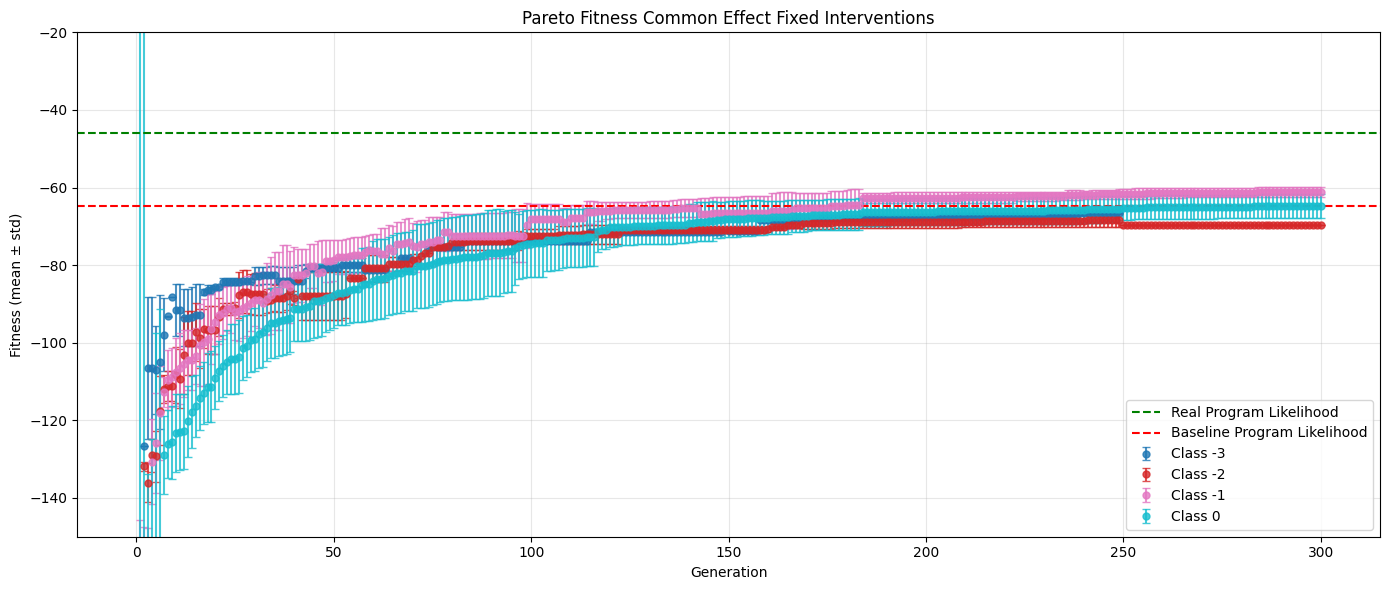

: 

In [ ]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -20])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

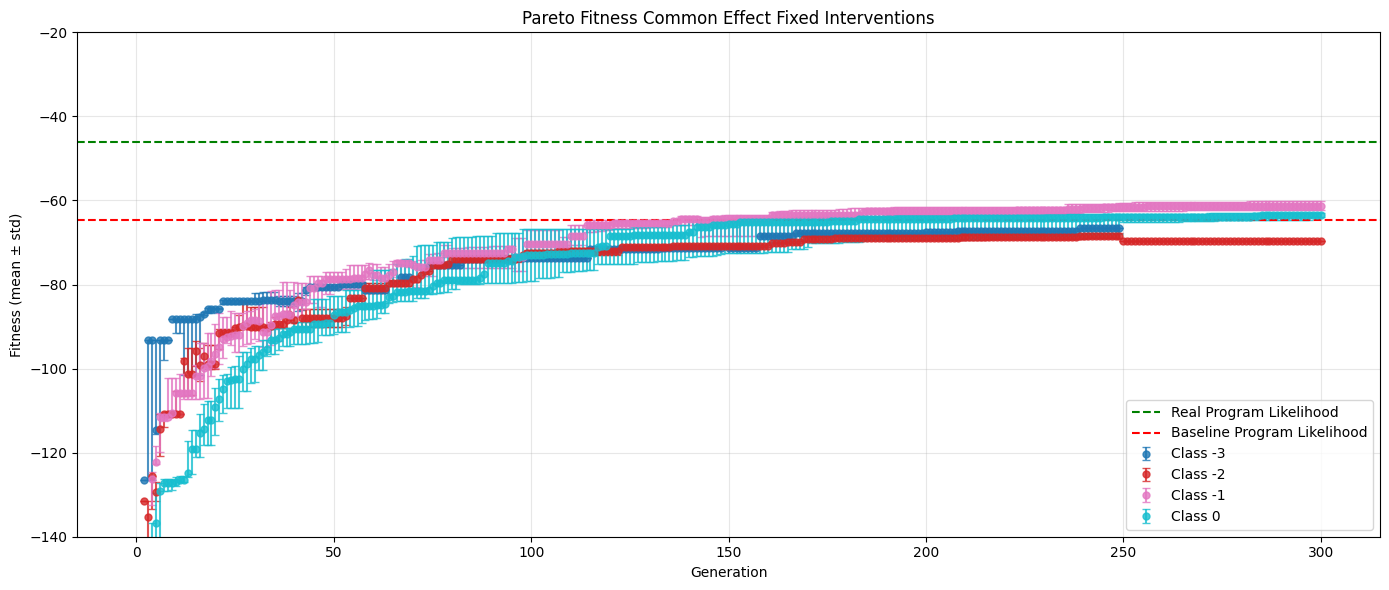

: 

In [ ]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_median'],
            yerr= [cls_df['fitness_median'] - cls_df['fitness_q1'], cls_df['fitness_q3'] - cls_df['fitness_median']],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-140, -20])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# using pareto_stats, for each class, generate a file txt with columns: generation, median_fitness, fitness_25perc, fitness_75perc
# separated by spaces, named 'class_' + class + '_fitness_summary'+ '.txt' and saved in ../results/synthesis/program
# with column headers: generation median_fitness fitness_25perc fitness_75perc

for cls in classes:
    cls_df = pareto_stats[pareto_stats['class'] == cls]
    output_fp = path.join('..', 'results', 'synthesis', program, f'class_{cls}_fitness_summary.txt')
    cls_df[['generation', 'fitness_median', 'fitness_q1', 'fitness_q3']].to_csv(
        output_fp,
        sep=' ',
        index=False,
        header=['generation', 'median_fitness', 'fitness_25perc', 'fitness_75perc']
    )



: 

In [ ]:
# find the folder that contains the best fitnes and in that folder open the folder first_front which contains files like 0.txt, 1.txt... and find the file
# that contains in the last row [best fitness, n] the best fitness and print the content of that file
# ...existing code...
# find the run folder that contains the best fitness, open its first_front/*.txt files,
# check the last non-empty row for [best_fitness, n] and print the matching file content
import math
from glob import glob

if pareto_fitness.empty:
    print("No pareto_fitness data available.")
else:
    best_idx = pareto_fitness['fitness'].idxmax()
    best_fitness = float(pareto_fitness.loc[best_idx, 'fitness'])
    best_runs = pareto_fitness[pareto_fitness['fitness'] == best_fitness]['run'].unique().tolist()
    print(f"Best fitness = {best_fitness}, candidate runs: {best_runs}")

    found = False
    for run in best_runs:
        run_dir = path.join(base_dir, run)
        ff_dirs = glob(path.join(run_dir, "**", "first_front"), recursive=True)
        for ff in ff_dirs:
            txt_files = sorted(glob(path.join(ff, "*.txt")))
            for txt_path in txt_files:
                with open(txt_path, "r") as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 1:
                    try:
                        val = float(last_row[0])
                    except Exception:
                        continue
                    if math.isclose(val, best_fitness, rel_tol=1e-9, abs_tol=1e-6):
                        print(f"Found matching file: {txt_path}")
                        print("---- file content ----")
                        print("\n".join(lines))
                        print("----------------------")
                        found = True
                        # Save the matching file content to a new file in ../results/synthesis
                        output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front.txt')
                        with open(output_file, 'w') as out_f:
                            out_f.write("\n".join(lines))
                        break
            if found:
                break
        if found:
            break

    if not found:
        print("No first_front/*.txt file found whose last row matches the best fitness.")
# ...existing code...

Best fitness = -59.88783508834393, candidate runs: ['e243-012.eduroam.tuwien.ac.at_26_1_20_151135_112283_97954_1']
Found matching file: ../results/common_effect_fixed_interventions/e243-012.eduroam.tuwien.ac.at_26_1_20_151135_112283_97954_1/first_front/1.txt
---- file content ----
Generation:
300
Phenotype:
2
V1 = gm([4, 9.7, 2]);
V2 = V1;
V2 = V2 + gm([16, 10.8, 5.7]);
V3 = 0.8;
V3 = V3 + gm([40, 4, 3]);
Pre-processed Program
:F = gm([1.000000], [9.7], [2]);T = F;T = T;T = T + gm([1.000000], [10.8], [5.7]);W = 0.8;W = W;W = W + gm([1.000000], [4], [3]);Genotype:
[153, 469, 250, 424, 423, 168, 79, 278, 186, 208, 53, 468, 375, 230, 410, 260, 194, 116, 112, 44, 458, 311, 222, 92, 368, 208, 16, 71, 112, 475, 223, 260, 258, 106, 208, 140, 301, 287, 459, 457, 358, 471, 140, 218, 278, 500, 397, 164, 361, 356, 309, 24, 187, 386, 388, 427, 264, 14, 483, 296, 305, 77, 328, 392, 286, 306, 33, 85, 148, 402, 395, 119, 489, 14, 192, 467, 84, 210, 275, 35, 127, 343, 359, 411, 272, 50, 452]
Tree:
Non

: 

In [ ]:
# find the best file per complexity (n) in the last evolution step across all runs
import os
import re
import ast
from glob import glob

def _extract_gen_num(p: str):
    parts = p.split(os.sep)
    for part in reversed(parts):
        m = re.search(r'(?:gen|generation)[_-]?(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
        m = re.fullmatch(r'g(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None

def _coerce_num(val):
    try:
        num = float(val)
    except Exception:
        return None
    if abs(num - round(num)) < 1e-9:
        return int(round(num))
    return num

if pareto_fitness.empty:
    print('No pareto_fitness data available.')
else:
    max_gen = pareto_fitness['generation'].max()
    if max_gen is not None:
        max_gen = int(max_gen)

    ff_dirs = glob(path.join(base_dir, '**', 'first_front'), recursive=True)
    if not ff_dirs:
        print('No first_front directory found under base_dir.')
    else:
        if max_gen is not None:
            filtered = [d for d in ff_dirs if _extract_gen_num(d) == max_gen]
        else:
            filtered = []
        if filtered:
            ff_dirs = filtered

        best_by_n = {}
        for ff_dir in ff_dirs:
            txt_files = sorted(glob(path.join(ff_dir, '*.txt')))
            for txt_path in txt_files:
                with open(txt_path, 'r') as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 2:
                    fitness = _coerce_num(last_row[0])
                    n_val = _coerce_num(last_row[1])
                    if fitness is None or n_val is None:
                        continue
                    current = best_by_n.get(n_val)
                    if current is None or fitness > current['fitness']:
                        best_by_n[n_val] = {
                            'fitness': fitness,
                            'path': txt_path,
                            'lines': lines,
                        }

        if not best_by_n:
            print('No valid first_front/*.txt files found for the last evolution step.')
        else:
            for n_val in sorted(best_by_n.keys()):
                entry = best_by_n[n_val]
                print(f'Best for n={n_val} (fitness={entry["fitness"]}): {entry["path"]}')
                print('---- file content ----')
                print('\n'.join(entry['lines']))
                print('----------------------')

                output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front_n_{n_val}.txt')
                with open(output_file, 'w') as out_f:
                    out_f.write('\n'.join(entry['lines']))


Best for n=-2 (fitness=-69.56205280464569): ../results/common_effect_fixed_interventions/e243-012.eduroam.tuwien.ac.at_26_1_20_151135_140913_97956_3/first_front/27.txt
---- file content ----
Generation:
300
Phenotype:
3
V1 = gm([32.3, 26.6, 7], [48, 19.8, 4.1], [43.4, 20, 1]) - uniform([14, 6], 2);
V2 = V1 - V1 + 8;
V2 = V2 + gm([32.3, 26.6, 7], [48, 19.8, 4.1], [43.4, 20, 1]) - uniform([14, 6], 2);
V3 = V2 - V1 + 8;
V3 = V3 + gm([32.3, 26.6, 7], [48, 19.8, 4.1], [43.4, 20, 1]) - uniform([14, 6], 2);
Pre-processed Program
:W = gm([0.261116, 0.388036, 0.350849], [26.6, 19.8, 20], [7, 4.1, 1]);W = W - uniform([14.000000, 20.000000], 2);F = W;F = F - W;F = F + 8;F = F;F = F + gm([0.261116, 0.388036, 0.350849], [26.6, 19.8, 20], [7, 4.1, 1]);F = F - uniform([14.000000, 20.000000], 2);T = F;T = T - W;T = T + 8;T = T;T = T + gm([0.261116, 0.388036, 0.350849], [26.6, 19.8, 20], [7, 4.1, 1]);T = T - uniform([14.000000, 20.000000], 2);Genotype:
[209, 266, 8, 259, 456, 55, 104, 118, 207, 407, 28

: 

In [ ]:
#read the structure.csv file in results/structures and print the number of elements in each row
structure_fp = path.join('..', 'results', 'structures', 'structure.csv')
with open(structure_fp, 'r') as f:
    for line in f:
        elements = line.strip().split()
        print(f'Number of elements in row: {len(elements)}')

Number of elements in row: 50
Number of elements in row: 46


: 

In [9]:
program = 'T = gm([0.037681, 0.260870, 0.701449], [33, 11, 12.6], [16.8, 19, 16]);if T > 36 {   TEMP0 = T * T;   F = TEMP0; } else {   F = 45;   F = F - T; } end if;F = F;F = F + 19.2 * uniform([16.000000, 37.900000], 3);F = F - 42 * uniform([7.000000, 12.000000], 3);F = F + uniform([12.000000, 24.700000], 3);F = F + 39 * gm([0.371585, 0.023679, 0.163934, 0.440801], [39.3, 33, 11, 12.6], [31, 16.8, 19, 16]);F = F - 47.1 * uniform([3.000000, 18.700000], 1);TEMP1 = F * F;C = TEMP1;C = C - F;C = C;C = C + 19.2 * uniform([16.000000, 37.900000], 3);C = C - 42 * uniform([7.000000, 12.000000], 3);C = C + uniform([12.000000, 24.700000], 3);C = C + 39 * gm([0.371585, 0.023679, 0.163934, 0.440801], [39.3, 33, 11, 12.6], [31, 16.8, 19, 16]);C = C - 47.1 * uniform([3.000000, 18.700000], 1);'
dataset_file = f'fitness/datasets/common_cause.csv'
data = np.loadtxt(dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(program, vars, data)



KeyboardInterrupt: 

In [5]:
sys.path.insert(1, '../SOGA-main/src')
from sogaPreprocessor import *
from producecfg import *
from libSOGA import *

soga_program = 'F = 0-1*T;'
compiledText=compile2SOGA_text(soga_program)
cfg = produce_cfg_text(compiledText)                               
output_dist = start_SOGA(cfg)



line 1:5 mismatched input '-1' expecting ';'


In [12]:
soga_program = '6\nV1 = gm([1.27e+2, -2.34e-1, 8.57e-0]);\nif V1 <= +1.18e+1 { \n   V2 = +V1 * -2.42e-3 + -7.56e+1 * +V1 * -4.73e-2; \n } else { \n   if V1 < +2.58e-3 { \n     V2 = +V1; \n   } else { \n     if V1 <= -9.13e-2 { \n       V2 = +2.52e-2 * -8.57e-0 * +1.94e-1 + -2.56e+0; \n     } else { \n       if V1 >= +2.75e+3 { \n         if V1 <= -5.68e-2 { \n           V2 = -3.72e-3 * -6.25e+1; \n         } else { \n           if V1 < +7.30e+1 { \n             V2 = -1.27e+2 + -1.58e-1 * -3.41e-0 - -V1 * -6.44e-3 + +V1 * -7.41e-3 - -V1 * +V1 + -2.97e-0 * +5.89e-0; \n           } else { \n             V2 = -V1; \n           } end if; \n         } end if; \n       } else { \n         V2 = -3.18e+3 * -V1; \n       } end if; \n     } end if; \n   } end if; \n } end if;\nV2 = V2 + gm([2.52e-2, -5.85e-3, 7.34e-3]);\nV3 = -2.56e+0 - +2.75e+3 * -5.77e-2 + +V2 * -V1;\nV3 = V3 + uniform([+9.73e+1, 2.58e-3], 2);'


perm, input_p = soga_fitness_SCM.extract_perm_and_strip_program(soga_program)
#p = normalize_program_by_blocks(p)
data_var_list, scm = dgp.get_vars('common_cause')
mapping = soga_fitness_SCM.perm_to_mapping(perm, data_var_list)
p = soga_fitness_SCM.preprocess_program(input_p)
p = soga_fitness_SCM.replace_variables_with_names(p, mapping)

print(p)
compiledText=compile2SOGA_text(p)
cfg = produce_cfg_text(compiledText)                               
output_dist = start_SOGA(cfg)

print(p)

T = gm([1.000000], [-0.234], [8.57]);if T <= 11.8 {   TEMP0 = -0.00242 * T;   TEMP1 = 3.5758799999999997 * T;   C = TEMP0;   C = C + TEMP1; } else {   if T < 0.00258 {     C = T;   } else {     if T <= -0.0913 {       C = 0;       C = C - 0.041897016;       C = C - 2.56;     } else {       if T >= 2750.0 {         if T <= -0.0568 {           C = 0.2325;         } else {           if T < 73.0 {             TEMP2 = 0.00644 * T;             TEMP3 = -0.00741 * T;             TEMP4 = T * T;             TEMP4 = -TEMP4;             C = 0;             C = C - 127;             C = C + 0.53878;             C = C - TEMP2;             C = C + TEMP3;             C = C - TEMP4;             C = C - 17.4933;           } else {             C = 0;             C = C - T;           } end if;         } end if;       } else {         TEMP5 = 3180 * T;         C = TEMP5;       } end if;     } end if;   } end if; } end if;C = C + gm([1.000000], [-0.00585], [0.00734]);TEMP6 = C * T;TEMP6 = -TEMP6;F = 0;F = F -

line 1:511 extraneous input '-' expecting {'gm(', 'uniform(', IDV, NUM}
line 1:980 extraneous input '-' expecting {'gm(', 'uniform(', IDV, NUM}


FloatingPointError: underflow encountered in exp